# Clasificación de Residuos — Modelo A2: CNN Small

---

## Contexto del Experimento

Este notebook forma parte de una **serie de experimentos de complejidad creciente** para estudiar el impacto de la arquitectura en el rendimiento de redes neuronales convolucionales aplicadas a la clasificación de residuos.

### Estrategia Experimental

- **Punto de partida**: Modelo baseline A1 (red simple del notebook 2.3)
- **Enfoque**: Incrementos progresivos en la capacidad del modelo
- **Observables**: Evolución del error de entrenamiento y validación

Cada modelo se implementa en un archivo independiente dentro de la carpeta `models/` del proyecto.

---

## **Arquitectura del Modelo A2**

### Descripción

**CNN Small** es el primer incremento de complejidad respecto al modelo baseline (A1). Mantiene la estructura general de A1, pero **aumenta la capacidad de representación** mediante el incremento de filtros convolucionales.

### Modificaciones Respecto a A1 (Modelo 2.3 Red Simple)

| Componente | A1 (Baseline) | A2 (Este modelo) |
|------------|---------------|------------------|
| **Filtros Conv** | 6 | **32** |
| Resto de arquitectura | — | Sin cambios |

**Hipótesis**: Este aumento de filtros debería permitir al modelo capturar más características visuales sin añadir capas adicionales.

---

### **RESUMEN FINAL: Comparación de rendimiento en el conjunto de Test**

| Modelo | Parámetros | Accuracy | Precision | Recall | F1-Score |
|------|---------:|---------:|----------:|-------:|--------:|
| A1  | 210 | 0.4921 | 0.4257 | 0.4326 | 0.4150 |
| A2 | 1,094 |0.61 | 0.66 | 0.56 | 0.57 |

##  Implementación

A continuación se entrena y evalúa el modelo A2 usando el pipeline estándar del proyecto.

In [1]:
# ========================================
# 1. IMPORTS Y CONFIGURACION
# ========================================

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import keras

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score, 
    recall_score, 
    f1_score  
)


# Agregar ruta del proyecto al path (carpeta padre de notebooks)
sys.path.insert(0, '..')

# Importar funciones de utilidad
from src.utils import initialize_project

2026-03-12 19:43:06.909755: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-12 19:43:06.909960: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-12 19:43:06.936935: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-12 19:43:07.562277: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

---
## 1. Carga de datos

In [2]:
# ========================================
# 2. CARGA DE DATOS Y CONFIGURACION
# ========================================

X_train, y_train, X_val, y_val, X_test, y_test, class_names = initialize_project()

Ejecutando en local

Cargando datos desde: /home/anuega/archivos/notebooks/../data/processed/trashnet_224x224.npz
  X.shape: (2527, 224, 224, 3)
  y.shape: (2527,)
  Clases: cardboard, glass, metal, paper, plastic, trash

División estratificada (seed=44):
  Train: 1768 imágenes (70%)
  Val:   379 imágenes (15%)
  Test:  380 imágenes (15%)


---
## 2. Definición del modelo

In [3]:
# ========================================
# 3. DEFINICION DEL MODELO A2
# ========================================

from models.A2_cnn_small import build_cnn_small as build_model

model = build_model(input_shape=(224, 224, 3), num_classes=6)
model.summary()

/home/anuega/miniconda3/envs/gcd/lib/python3.10/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1773340992.507971 1190147 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773340992.517083 1190147 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "A2_CNN_Small"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,094 (4.27 KB)

 Trainable params: 1,094 (4.27 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
def plot_training(history, title='', phase=1):
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    epochs   = range(1, len(loss) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(18, 10))
    fig.suptitle(f'{title} — Fase {phase}', fontsize=14, fontweight='bold')

    # ── Fila 1: Loss ─────────────────────────────────────────────────────────
    # 1a) Curva completa
    axes[0].plot(epochs, loss,     label='Train')
    axes[0].plot(epochs, val_loss, label='Validación')
    axes[0].set_title('Loss — Completa')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
    axes[0].legend()

    # ── Fila 2: Accuracy ─────────────────────────────────────────────────────
    axes[1].plot(epochs, acc,     label='Train')
    axes[1].plot(epochs, val_acc, label='Validación')
    axes[1].set_title('Accuracy — Completa')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
    axes[1].legend()


    plt.tight_layout()
    plt.savefig(f'curvas_{MODEL_NAME}_fase{phase}.png', dpi=150)
    plt.show()


---
## 3. Entrenamiento


In [ ]:
HAS_PHASE2 = True
MODEL_NAME = 'A2_CNN_Small'

cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=15, min_lr=1e-6, verbose=1)

cb_checkpoint = callbacks.ModelCheckpoint(
    filepath=f'best_{MODEL_NAME}_phase1.keras',
    monitor='val_accuracy', # ← antes era val_loss
    mode='max', # ← accuracy se maximiza
    save_best_only=True
)

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=3e-3,
        weight_decay=1e-4  # ← L2 regularization
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_p1 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=800,
    callbacks=[ cb_reduce_lr, cb_checkpoint],
    verbose=1
)

Epoch 1/800
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.2296 - loss: 1.7240 - val_accuracy: 0.2375 - val_loss: 1.7103 - learning_rate: 0.0030
Epoch 2/800
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.2342 - loss: 1.7026 - val_accuracy: 0.3008 - val_loss: 1.6918 - learning_rate: 0.0030
Epoch 3/800
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.2805 - loss: 1.6798 - val_accuracy: 0.3430 - val_loss: 1.6664 - learning_rate: 0.0030
Epoch 4/800
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.3258 - loss: 1.6515 - val_accuracy: 0.3668 - val_loss: 1.6384 - learning_rate: 0.0030
Epoch 5/800
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.3563 - loss: 1.6213 - val_accuracy: 0.3509 - val_loss: 1.6102 - learning_rate: 0.0030
Epoch 6/800
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.3722 - loss: 1.5969 - val_accuracy: 0.3694 - val_loss: 1.5908 - learning_rate: 0.0030
Epoch 7/800
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.3614 - loss: 1.5799 - 

---
## 4. Curvas de entrenamiento

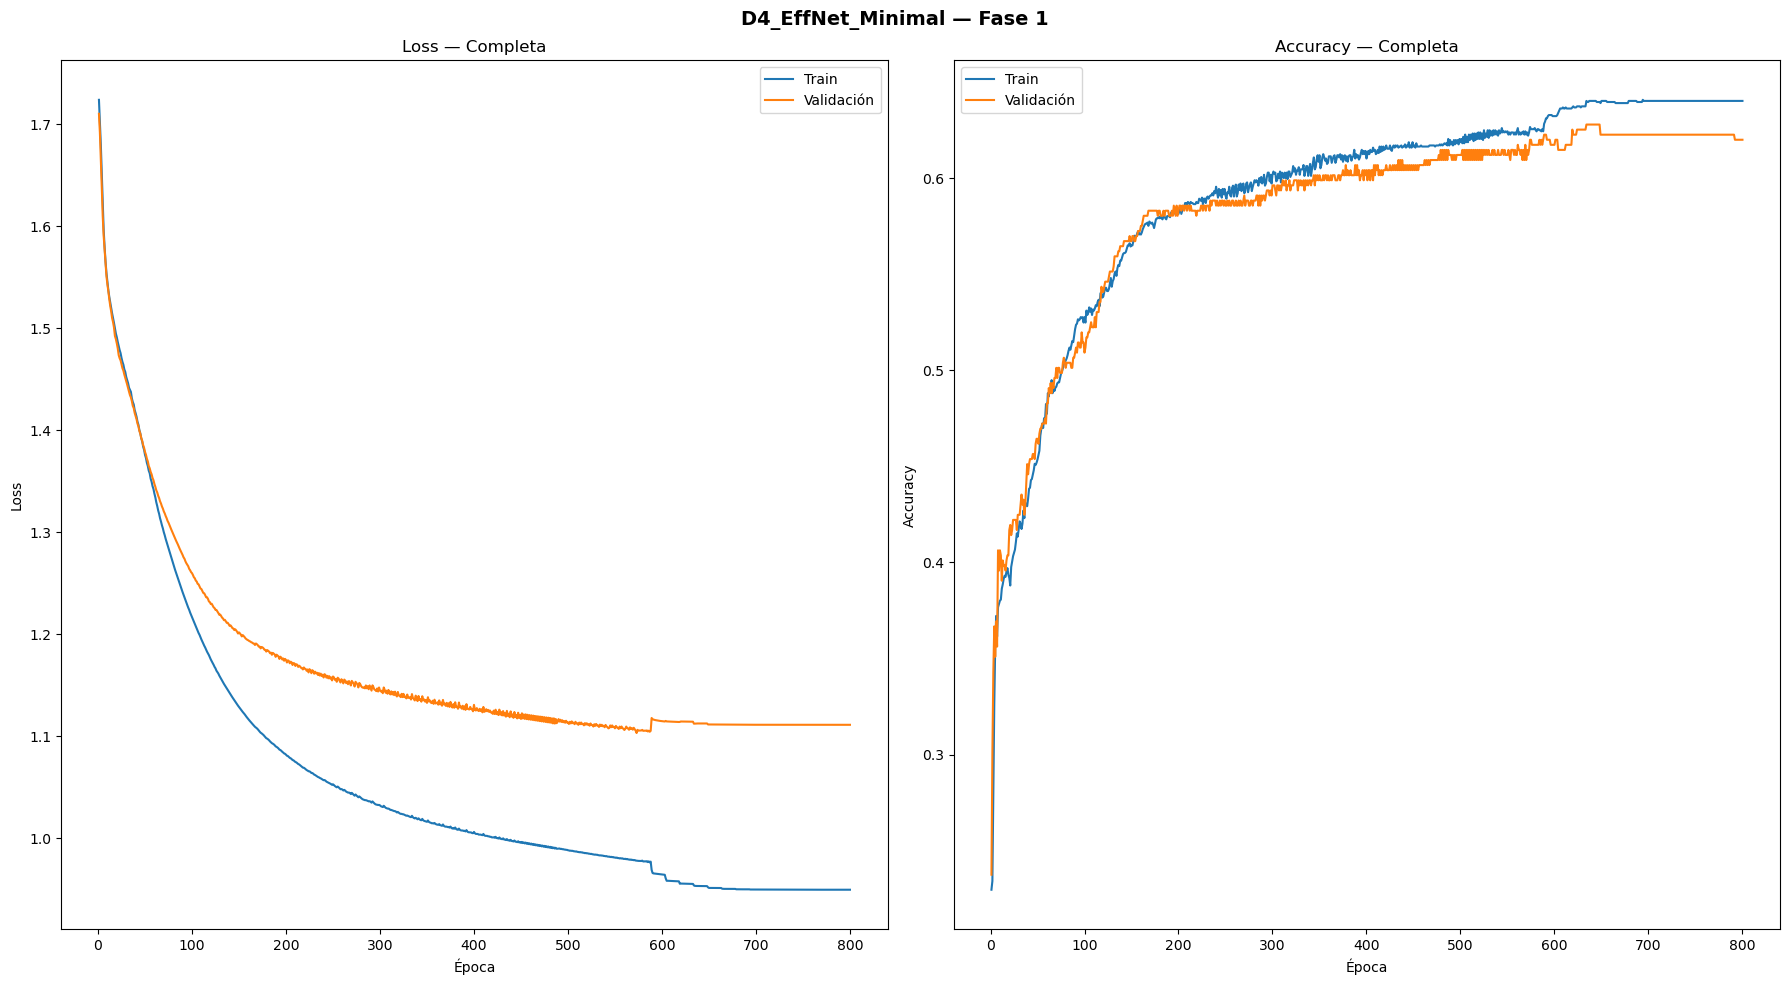

In [6]:
plot_training(history_p1, title=MODEL_NAME, phase=1)

### Versión diferente de entrenamiento entrenando con scheduler coseno
Entrenando usando el scheduler coseno converge en 200 épocas pero los resultados obtenidos no son tan buenos como en el anterior caso. Por lo tanto, nos quedamos con la versión anterior. 

In [ ]:
# # ========================================
# # 4. CONFIGURACION Y ENTRENAMIENTO
# # ========================================

# MODEL_NAME = 'A2_cnn_small'

# # ── Learning Rate Scheduler ──────────────────────────────────────────────────
# batch_size = 64
# steps_per_epoch = max(1, len(X_train) // batch_size)
# total_steps = steps_per_epoch * 200

# lr_scheduler = keras.optimizers.schedules.CosineDecay(
#     initial_learning_rate=0.01,
#     decay_steps=total_steps,
#     alpha=0.0001
    
# )

# # ── Callbacks ───────────────────────────────────────────────────────────────
# cb_checkpoint = callbacks.ModelCheckpoint(
#     filepath=f'best_{MODEL_NAME}_phase1.keras',
#     monitor='val_loss', save_best_only=True, verbose=0)

# # ── Compilar ─────────────────────────────────────────────────────────────────
# model.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=lr_scheduler),
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# # ── Entrenamiento ────────────────────────────────────────────────────────────
# history_p1 = model.fit(
#     X_train, y_train,
#     validation_data=(X_val, y_val),
#     epochs=200,
#     callbacks=[cb_checkpoint],
#     verbose=1,
#     batch_size=batch_size
# )

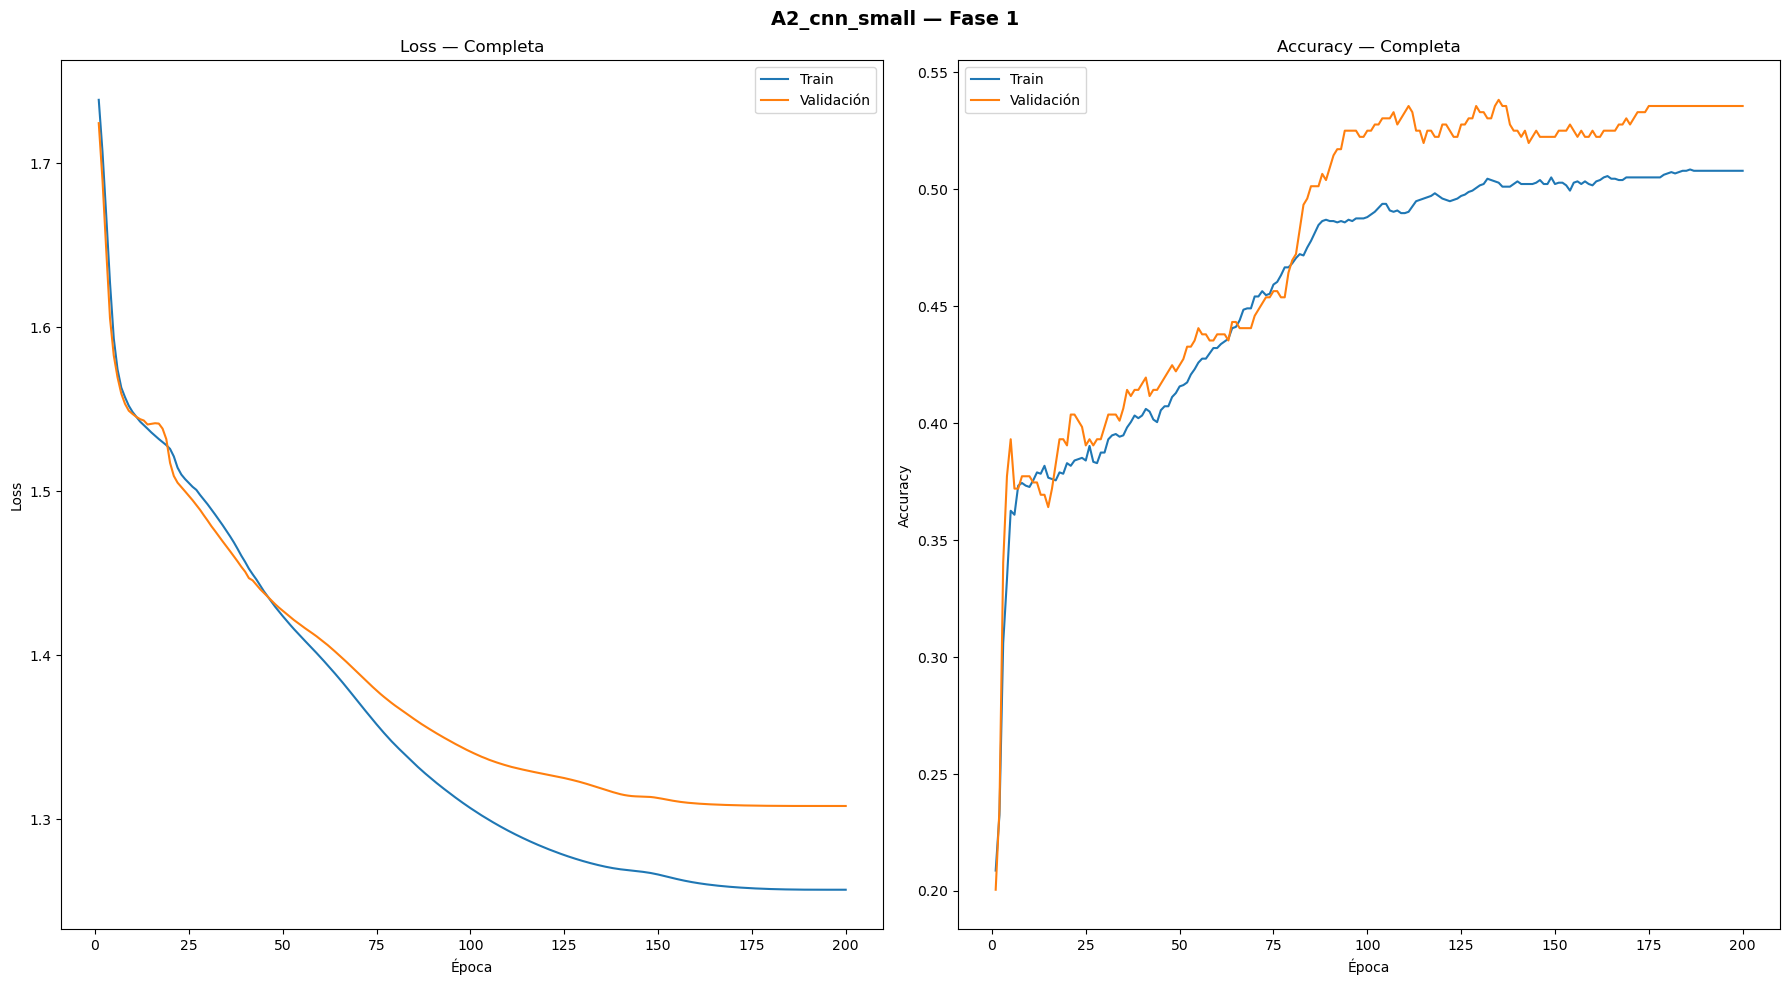

---
## 5. Evaluación — Train / Val / Test

In [ ]:
def evaluate_split(model, X, y, split_name):
    """Calcula y muestra Accuracy, Precision, Recall y F1-macro."""
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y, y_pred, average='macro', zero_division=0)
    print(f'[{split_name:>5}]  Acc={acc:.4f}  Prec={prec:.4f}  '
          f'Rec={rec:.4f}  F1={f1:.4f}')
    return {'split': split_name, 'acc': acc,
            'prec': prec, 'rec': rec, 'f1': f1, 'y_pred': y_pred}


print('=' * 60)
print(f'Modelo: {MODEL_NAME}')
print('=' * 60)
res_train = evaluate_split(model, X_train, y_train, 'Train')
res_val   = evaluate_split(model, X_val,   y_val,   'Val')
res_test  = evaluate_split(model, X_test,  y_test,  'Test')
print('=' * 60)

In [11]:
# ── Número de parámetros (para la tabla del README) ──────────────────────────
total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])

print(f'Parámetros totales    : {total_params:,}')
print(f'Parámetros entrenables: {trainable_params:,}')

Parámetros totales    : 1,094
Parámetros entrenables: 1,094


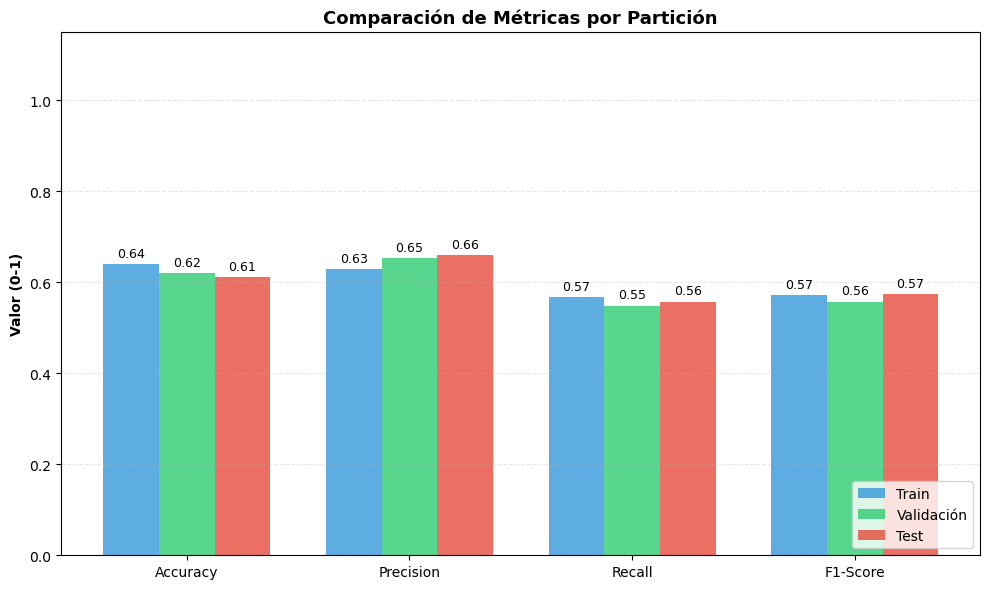

In [15]:
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_names))
width = 0.25

# Obtener resultados de las métricas
results_train = [res_train['acc'], res_train['prec'], res_train['rec'], res_train['f1']]
results_val = [res_val['acc'], res_val['prec'], res_val['rec'], res_val['f1']]
results_test = [res_test['acc'], res_test['prec'], res_test['rec'], res_test['f1']]

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width, results_train, width, label='Train', color='#3498db', alpha=0.8)
rects2 = ax.bar(x, results_val, width, label='Validación', color='#2ecc71', alpha=0.8)
rects3 = ax.bar(x + width, results_test, width, label='Test', color='#e74c3c', alpha=0.8)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

ax.set_ylabel('Valor (0-1)', fontweight='bold')
ax.set_title('Comparación de Métricas por Partición', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

---
## 6. Matriz de confusión

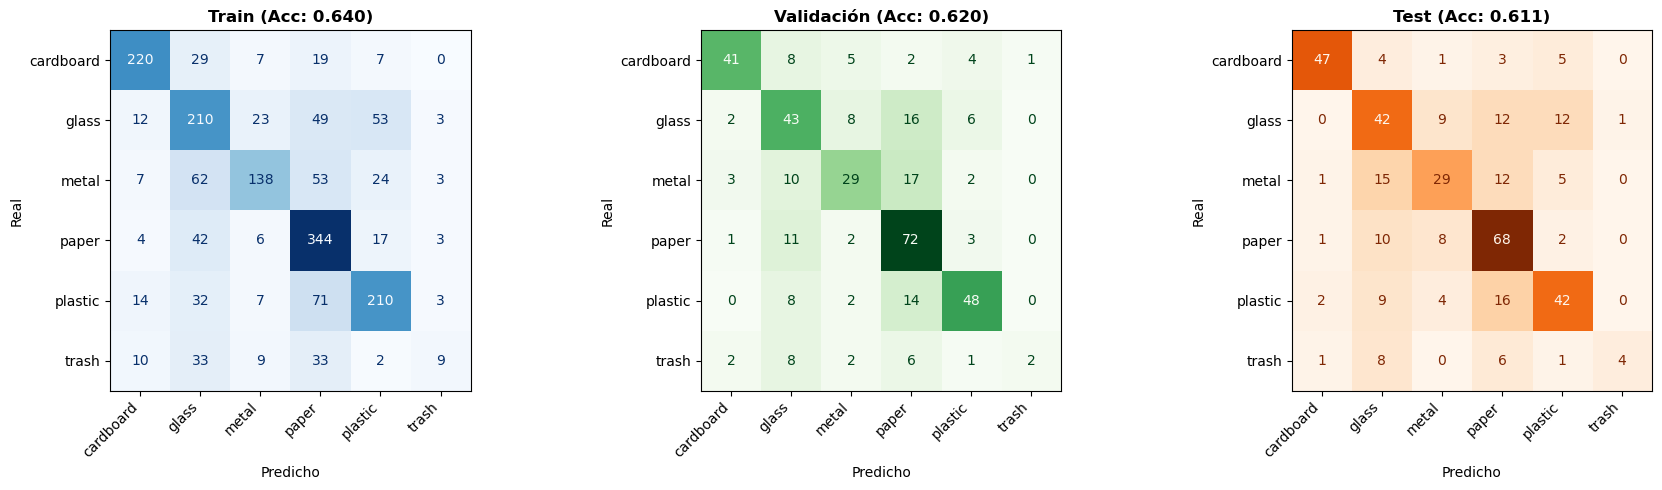

In [16]:
# Matrices de confusión para Train, Val y Test
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

y_pred_train = res_train['y_pred']
y_pred_val   = res_val['y_pred']
y_pred_test  = res_test['y_pred']

# Train
cm_train = confusion_matrix(y_train, y_pred_train)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=class_names)
disp_train.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Train (Acc: {results_train[0]:.3f})", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Predicho", fontsize=10)
axes[0].set_ylabel("Real", fontsize=10)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Validación
cm_val = confusion_matrix(y_val, y_pred_val)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=class_names)
disp_val.plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title(f"Validación (Acc: {results_val[0]:.3f})", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Predicho", fontsize=10)
axes[1].set_ylabel("Real", fontsize=10)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Test
cm_test = confusion_matrix(y_test, y_pred_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
disp_test.plot(ax=axes[2], cmap="Oranges", colorbar=False)
axes[2].set_title(f"Test (Acc: {results_test[0]:.3f})", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Predicho", fontsize=10)
axes[2].set_ylabel("Real", fontsize=10)
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 7. Conclusiones — Modelo A2 (CNN Small)

El modelo **A2_CNN_Small** mejora la capacidad de representación respecto a A1 al aumentar el número de filtros convolucionales.  
En este experimento se observa que:

- El entrenamiento requirió **muchas épocas** para converger (hasta ~800), lo que sugiere una optimización más lenta de lo esperado.
- Observando las métricas vemos que el modelo generaliza correctamente sin presentar sobreajuste.
- Se probó también una variante con **scheduler CosineDecay** (código comentado), útil para analizar estabilidad del entrenamiento y velocidad de convergencia.
- Frente al baseline A1, A2 muestra una evolución en métricas que confirma el impacto de aumentar la capacidad del modelo.

### Comparación de modelos: A1 vs A2

| Modelo | Partición | Accuracy | Precision | Recall | F1-Score |
|------|-----------|---------:|----------:|-------:|--------:|
| A1 (SimpleCNN) | Train | 0.4717 | 0.4138 | 0.4100 | 0.3937 |
| A1 (SimpleCNN) | Validación | 0.4802 | 0.4406 | 0.4138 | 0.4030 |
| A1 (SimpleCNN) | Test | 0.4921 | 0.4257 | 0.4326 | 0.4150 |
| A2 (Actual)| Train | 0.64 | 0.63 | 0.57 | 0.57 |
| A2 | Validación | 0.62 | 0.65 | 0.55 | 0.56 |
| A2 | Test | 0.61 | 0.66 | 0.56 | 0.57 |


### Comparación de rendimiento en el conjunto de Test

| Modelo | Accuracy | Precision | Recall | F1-Score |
|------|---------:|----------:|-------:|--------:|
| A1 (SimpleCNN) | 0.4921 | 0.4257 | 0.4326 | 0.4150 |
| A2 | 0.61 | 0.66 | 0.56 | 0.57 |